# Lab 4

In [284]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Questions

#### 1. Consider the Table Contains the Average Annual Gold Rate from 1965 – 2022. Gold prices fluctuated throughout the year 2020 because of the COVID-19 epidemic. With gold functioning as a safe haven for investors, demand for the precious metal grew, and its price followed suit. During the epidemic, the stock market weakened, but it began to recover by the end of 2020 when the price of gold fell slightly. It’s crucial to remember that gold prices fluctuate during the year, and the figure below represents the average price for that year. With the exception of a few lows shared across a few years, the table shows that the gold price trend has always been upward, supporting the claim that gold is a secure investment over extended periods of time.

1.1 Create CSV file and write a python program to find the fitted simple linear regression equation for the given data.

In [285]:
gold = pd.read_csv("gold.csv")
gold.head()

,year,price
0,1965,72
1,1966,84
2,1967,103
3,1968,162
4,1969,176


In [286]:
X_g = gold["year"]
y_g = gold["price"]

In [287]:
n = len(X_g)

b_g = (n * (X_g * y_g).sum() - X_g.sum() * y_g.sum()) / \
    (n * (X_g * X_g).sum() - X_g.sum() ** 2)

a_g = (y_g.sum() - b_g * X_g.sum()) / n

print(f"Intercept: {a_g}")
print(f"Slope: {b_g}")

print(f"y = {a_g:.4f} + {b_g:.4f}x")

Intercept: -1334974.5943892458
Slope: 674.7124488603156
y = -1334974.5944 + 674.7124x


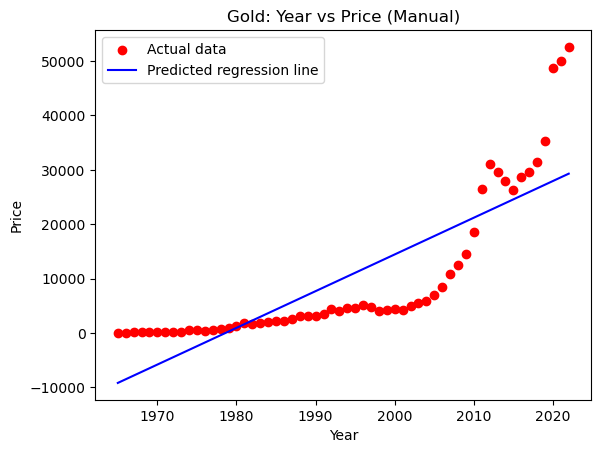

In [288]:
y_g_pred = a_g + b_g * X_g

plt.scatter(X_g, y_g, color='red', label='Actual data')
plt.plot(X_g, y_g_pred, color='blue', label='Predicted regression line')

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Gold: Year vs Price (Manual)')

plt.legend()
plt.show()

1.2 Compare the coefficients obtained from ```sklearn``` model with your program.

In [289]:
from sklearn.linear_model import LinearRegression

X_g = gold[["year"]]
y_g = gold[["price"]]

model = LinearRegression()
model.fit(X_g, y_g)

b_g_sk = model.coef_[0]
a_g_sk = model.intercept_

print(f"Intercept: {a_g_sk}")
print(f"Slope: {b_g_sk}")

print(f"y = {a_g_sk.item():.4f} + {b_g_sk.item():.4f}x")

Intercept: [-1334974.59438925]
Slope: [674.71244886]
y = -1334974.5944 + 674.7124x


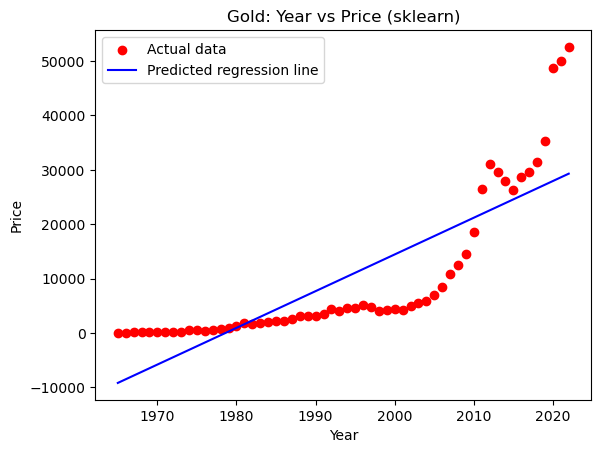

In [290]:
y_g_pred_sk = a_g_sk + b_g_sk * X_g

plt.scatter(X_g, y_g, color='red', label='Actual data')
plt.plot(X_g, y_g_pred_sk, color='blue', label='Predicted regression line')

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Gold: Year vs Price (sklearn)')

plt.legend()
plt.show()

In [291]:
comparison_g = pd.DataFrame({
    "model": ["manual", "sklearn"],
    "intercept (a)": [a_g, a_g_sk.item()],
    "slope (b)": [b_g, b_g_sk.item()]
})

comparison_g

,model,intercept (a),slope (b)
0,manual,-1.334975e+06,674.712449
1,sklearn,-1.334975e+06,674.712449


1.3 Compute the error, MSE and RMSE.

In [292]:
y_g = gold["price"].to_numpy(dtype=float)
y_g_pred = np.asarray(y_g_pred, dtype=float).ravel()

err_g = y_g - y_g_pred

mse_g = np.mean(err_g ** 2)
rmse_g = np.sqrt(mse_g)

print(f"MSE: {mse_g}")
print(f"RMSE: {rmse_g}")

MSE: 62353084.41830737
RMSE: 7896.396926339719


1.4 Predict the gold price with the year 2025 for 1 gram.

In [293]:
print(f"Gold price for 2025 (1g): {(a_g + b_g * 2025) / 10}")

Gold price for 2025 (1g): 3131.811455289321


#### 2. Consider the Question no 1 gold price with following year-wise silver price.

2.1 Create a CSV file and write a python program to find the fitted multiple linear regression equation for the given data.

In [294]:
silver = pd.read_csv("silver.csv")
silver.head()

,year,price
0,1981,2715
1,1982,2720
2,1983,3105
3,1984,3570
4,1985,3955


In [295]:
X_s = silver["year"]
y_s = silver["price"]

In [296]:
n = len(X_s)

b_s = (n * (X_s * y_s).sum() - X_s.sum() * y_s.sum()) / \
    (n * (X_s * X_s).sum() - X_s.sum() ** 2)

a_s = (y_s.sum() - b_s * X_s.sum()) / n

print(f"Intercept: {a_s}")
print(f"Slope: {b_s}")

print(f"y = {a_s:.4f} + {b_s:.4f}x")

Intercept: -2759150.879372282
Slope: 1388.7457256300138
y = -2759150.8794 + 1388.7457x


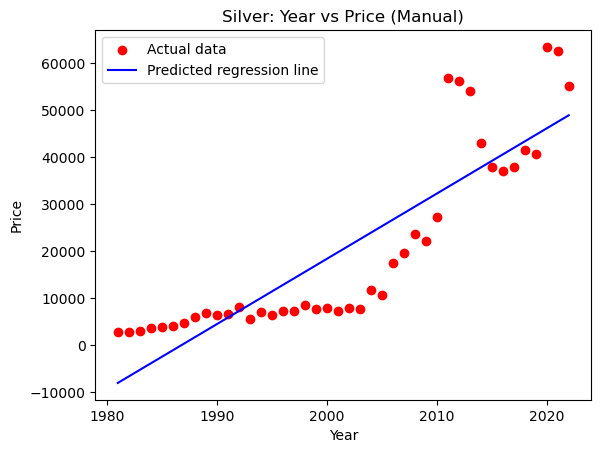

In [297]:
y_s_pred = a_s + b_s * X_s

plt.scatter(X_s, y_s, color='red', label='Actual data')
plt.plot(X_s, y_s_pred, color='blue', label='Predicted regression line')

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Silver: Year vs Price (Manual)')

plt.legend()
plt.show()

2.2 Compare the coefficients obtained from ```sklearn``` model with your program.

In [298]:
from sklearn.linear_model import LinearRegression

X_s = gold[["year"]]
y_s = gold[["price"]]

model = LinearRegression()
model.fit(X_s, y_s)

b_s_sk = model.coef_[0]
a_s_sk = model.intercept_

print(f"Intercept: {a_s_sk}")
print(f"Slope: {b_s_sk}")

print(f"y = {a_s_sk.item():.4f} + {b_s_sk.item():.4f}x")

Intercept: [-1334974.59438925]
Slope: [674.71244886]
y = -1334974.5944 + 674.7124x


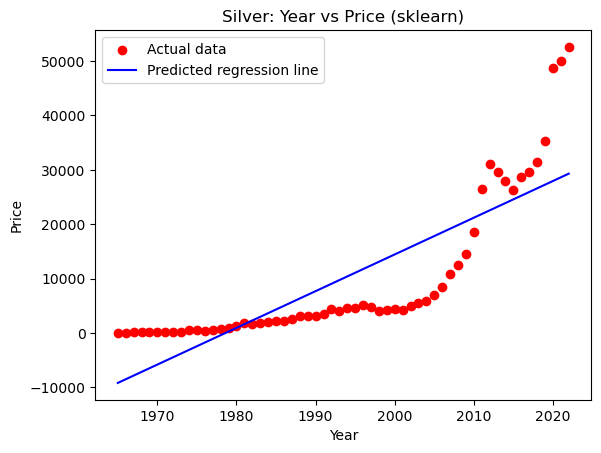

In [299]:
y_s_pred_sk = a_s_sk + b_s_sk * X_s

plt.scatter(X_s, y_s, color='red', label='Actual data')
plt.plot(X_s, y_s_pred_sk, color='blue', label='Predicted regression line')

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Silver: Year vs Price (sklearn)')

plt.legend()
plt.show()

In [300]:
comparison_s = pd.DataFrame({
    "model": ["manual", "sklearn"],
    "intercept (a)": [a_s, a_s_sk.item()],
    "slope (b)": [b_s, b_s_sk.item()]
})

comparison_s

,model,intercept (a),slope (b)
0,manual,-2.759151e+06,1388.745726
1,sklearn,-1.334975e+06,674.712449


2.3 Compute the error, MSE and RMSE.

In [301]:
y_s = silver["price"].to_numpy(dtype=float)
y_s_pred = np.asarray(y_s_pred, dtype=float).ravel()

err_s = y_s - y_s_pred

mse_s = np.mean(err_s ** 2)
rmse_s = np.sqrt(mse_s)

print(f"MSE: {mse_s}")
print(f"RMSE: {rmse_s}")

MSE: 94699881.65523118
RMSE: 9731.38641999336


2.4 Predict the gold and silver price with the year 2024 for 1 gram.

In [302]:
print(f"Gold price for 2024 (1g): {(a_g + b_g * 2025) / 10}")
print(f"Silver price for 2024 (1g): {(a_s + b_s * 2024) / 1000}")

Gold price for 2024 (1g): 3131.811455289321
Silver price for 2024 (1g): 51.670469302866145
